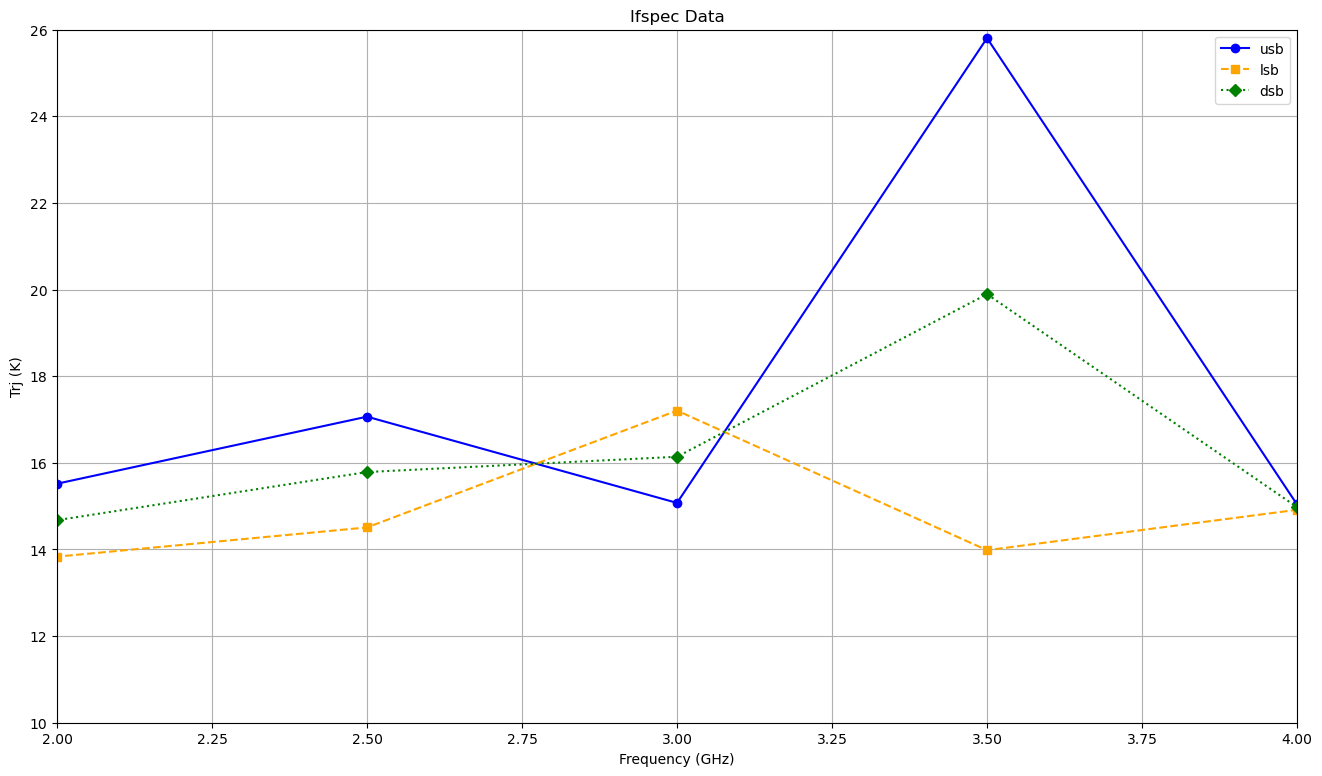

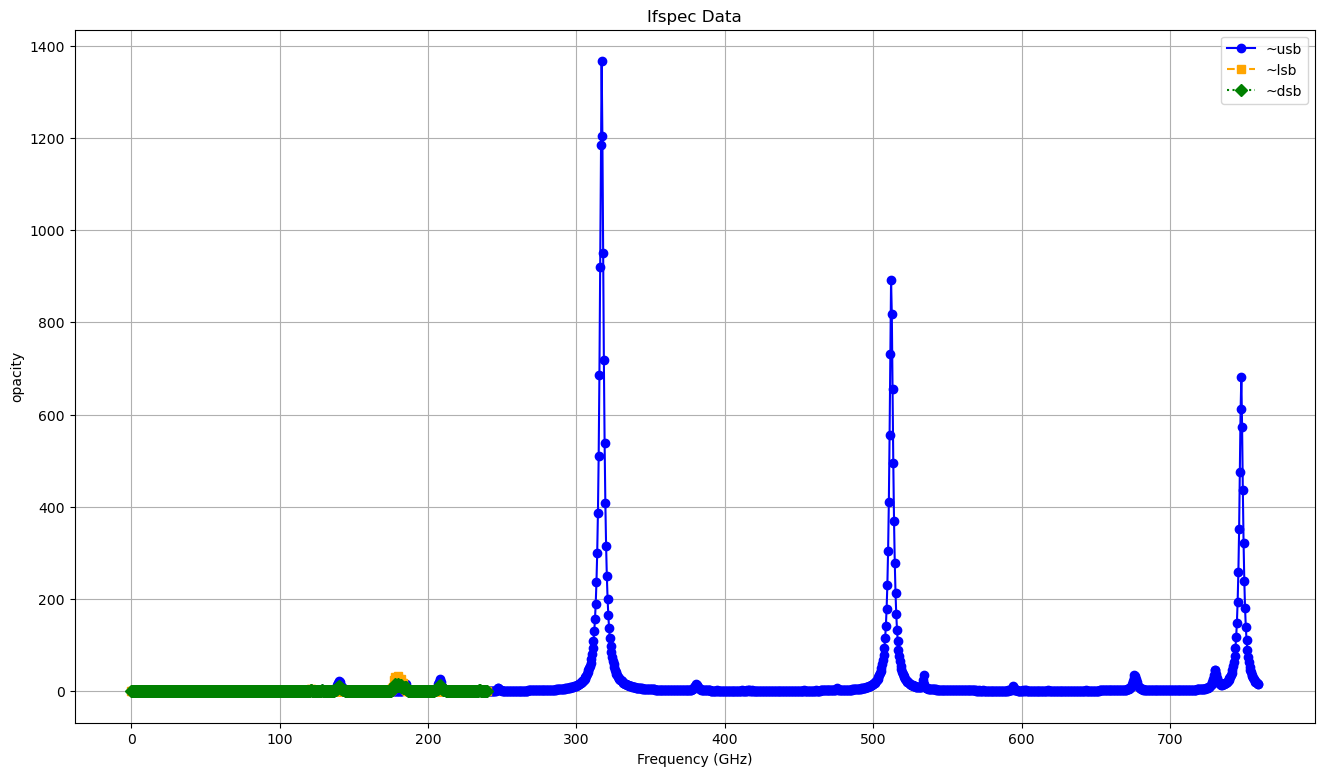

In [ ]:
from typing import Dict
import matplotlib.pyplot as plt
import numpy as np
from astropy import units as u
import os

names = ["usb", "lsb", "dsb" ]
out_dict: Dict[str, Dict[str,list]] = {}
#load the data  
for name in names:
    output_file = f"{name}240.txt"

    if not os.path.exists(output_file):
        raise FileNotFoundError(f"Output file {name}.out does not exist.")
    
    
    output_data = np.loadtxt(output_file)

    # Create a dictionary to hold the data


    for row in output_data:
        key = f"{name}"
        if key not in out_dict:
            out_dict[key] = {"frequencies": [], "brightness_temperature": [], "Trj": [], "opacity": []}
    
        
        out_dict[key]["frequencies"].append(row[0])
        out_dict[key]["brightness_temperature"].append(row[2])
        out_dict[key]["opacity"].append(row[1])
        out_dict[key]["Trj"].append(row[3])

        
#print(out_dict)

# fre = output_data[:, 0] * u.GHz
# Tb = output_data[:, 1] * u.K

colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink', 'gray', 'olive', 'darkblue']
linestyles = ['-', '--', ':', '-.', '-', '--', ':', '-.', '-', '--']
markers = ['o', 's', 'D', '^', 'v', '<', '>', 'p', '*', 'h']


fig0,ax0 = plt.subplots(figsize=(16, 9))
fig1,ax1 = plt.subplots(figsize=(16, 9))

for key in out_dict:
    fre = np.array(out_dict[key]["frequencies"]) * u.GHz
    Tb = np.array(out_dict[key]["brightness_temperature"]) * u.K
    opa = np.array(out_dict[key]["opacity"]) * u.one
    Trj = np.array(out_dict[key]["Trj"]) * u.K

    #plot the data
    ax0.plot(fre.value, Trj.value, label=f"{key}", color=colors[0], linestyle=linestyles[0], marker=markers[0])
    ax0.set_xlabel('Frequency (GHz)')
    ax0.set_ylabel('Trj (K)')
    ax0.set_title('Ifspec Data')
    ax0.grid(True)
    ax0.legend()

    ax1.plot(fre.value, opa.value, label=f"~{key}", color=colors.pop(0), linestyle=linestyles.pop(0), marker=markers.pop(0))
    ax1.set_xlabel('Frequency (GHz)')
    ax1.set_ylabel('opacity')
    ax1.set_title('Ifspec Data')
    ax1.grid(True)
    ax1.legend()

ax0.set_xlim(2,4)
ax0.set_ylim(10, 26)
fig0.savefig("ifspec 240GHz_zoomin_Trj 1.png", dpi=300, bbox_inches='tight')

#fig1.savefig("ifspec 240GHz_all_opacity.png", dpi=300, bbox_inches='tight')

plt.show()
